# Kaggle Phase 4 — Drift Detection & Adaptive Streaming Evaluation

Fourth of 4 notebooks. **All drift-aware work lives here now** (moved out of Phase 3):
the chronological streaming evaluation with `DriftMonitor` (moving-average + z-score
error checks) triggering `OnlineAdapter` (error-triggered incremental fine-tuning) with
`AdaptiveThreshold` tracking a rolling confidence band, the static-vs-adaptive
comparison, plus fully instrumented per-chunk logging and an automated diagnosis of
why/when retraining stops firing.

**Requires THREE datasets attached via Add Input:**
1. `kagglephase1-output` — features/windows/masks from `kagglephase1`
2. `kagglephase2-defs` — `model_defs.py` from `kagglephase2`
3. `kagglephase3-output` — the unzipped contents of `kagglephase3_output.zip`
   (download from Phase 3's Output tab after it finishes; contains the trained
   `checkpoints/gru_h{h}_static.pt` files plus all Phase 3 metrics)

No training from scratch happens here — only loading Phase 3's checkpoints, streaming
inference, and drift-triggered incremental updates.


## Step 1: Locate All 3 Inputs + Import from model_defs.py

In [20]:
import os, sys, gc, json, time
import numpy as np
from pathlib import Path

IN_KAGGLE = os.path.exists('/kaggle')
inp = Path('/kaggle/input') if IN_KAGGLE else Path('.')

hits1 = sorted(inp.glob('**/features_injected.npy'), key=lambda p: len(p.parts))
if not hits1:
    raise FileNotFoundError(
        "Phase-1 output not found -- attach the 'kagglephase1-output' dataset via Add Input."
    )
P1 = hits1[0].parent

hits2 = sorted(inp.glob('**/model_defs.py'), key=lambda p: len(p.parts))
if not hits2:
    raise FileNotFoundError(
        "model_defs.py not found -- attach the 'kagglephase2-defs' dataset via Add Input."
    )
sys.path.insert(0, str(hits2[0].parent))

hits3 = sorted(inp.glob('**/gru_h*_static.pt'), key=lambda p: len(p.parts))
if not hits3:
    raise FileNotFoundError(
        "No trained checkpoints (gru_h*_static.pt) found -- download kagglephase3_output.zip "
        "from Phase 3's Output tab, unzip, upload the files as a Kaggle Dataset named "
        "'kagglephase3-output', and attach it via Add Input."
    )
CKPT_DIR = hits3[0].parent
available_horizons = sorted(int(p.stem.split('_h')[1].split('_')[0])
                            for p in CKPT_DIR.glob('gru_h*_static.pt'))

from model_defs import (AdaptiveGRUModel, make_loader, predict_all, compute_metrics,
                        DriftMonitor, AdaptiveThreshold, OnlineAdapter)
import torch
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Phase-1 input   : {P1}")
print(f"model_defs      : {hits2[0]}")
print(f"checkpoints dir : {CKPT_DIR}  (horizons available: {available_horizons})")
print(f"device          : {device}")

p3_metrics = sorted(inp.glob('**/all_metrics.json'), key=lambda p: len(p.parts))
if p3_metrics:
    _p3 = json.load(open(p3_metrics[0]))
    print(f"Phase-3 metrics loaded for reference: horizons {list(_p3.get('static_results', {}).keys())}")


Phase-1 input   : /kaggle/input/datasets/thanakaran/kagglephase1-output
model_defs      : /kaggle/input/datasets/thanakaran/kagglephase2-defs/model_defs.py
checkpoints dir : /kaggle/input/datasets/thanakaran/phase3-output/kagglephase3_output/checkpoints  (horizons available: [1, 2, 3])
device          : cuda
Phase-3 metrics loaded for reference: horizons ['1', '2', '3']


## Step 2: Load Phase 1 Data + Config (mirrors Phase 3's model settings)

In [21]:
fc = json.load(open(P1 / 'feature_cols.json'))
stats = json.load(open(P1 / 'normalization_stats.json'))
TARGET_NAMES = fc['target_names']
TARGET_IDX = fc['target_idx']
TARGET_MEAN = np.array([stats[c]['mean'] for c in fc['target_columns']])
TARGET_STD  = np.array([stats[c]['std']  for c in fc['target_columns']])
FEAT_INJ = P1 / 'features_injected.npy'
windows_test = np.load(P1 / 'windows_test.npy')
spike_mask = np.load(P1 / 'spike_mask.npy')

HORIZONS = available_horizons        # e.g. [1, 2, 3] from Phase 3
HIDDEN_SIZE, NUM_LAYERS, DROPOUT = 128, 2, 0.2   # must match Phase 3's Phase3Config
EVAL_BATCH_SIZE = 512
STREAM_CHUNK = 768
ADAPT_LR, ADAPT_RECENT, ADAPT_BATCH_SIZE = 1e-4, 4096, 128
SPIKE_LOOKBACK_TAIL = 60
DEBUG_HORIZON = max(available_horizons)   # which horizon gets per-chunk debug logging

print(f"Streaming horizons: {HORIZONS} | test windows: {len(windows_test):,} | "
      f"chunk={STREAM_CHUNK} -> ~{int(np.ceil(len(windows_test)/STREAM_CHUNK))} chunks | "
      f"debug horizon: {DEBUG_HORIZON}")


Streaming horizons: [1, 2, 3] | test windows: 33,343 | chunk=768 -> ~44 chunks | debug horizon: 3


## Step 3: Streaming Drift-Aware Evaluation — Static vs. Adaptive (moved from Phase 3)

Two passes per horizon over the same chronological stream of injected-test windows:
- **static**: frozen Phase-3 checkpoint.
- **adaptive**: `DriftMonitor` watches chunk-level error (EWMA + z-score vs. a frozen
  reference window); on sustained breach, `OnlineAdapter` fine-tunes on recent
  already-seen windows (their targets are in the stream's past — no future
  information; the trailing 10 windows are excluded to respect the max-horizon
  overlap). `AdaptiveThreshold` maintains a rolling P50/P90 confidence band throughout.


In [22]:
def load_static_model(h):
    ckpt = torch.load(str(CKPT_DIR / f'gru_h{h}_static.pt'), map_location=device)
    m = AdaptiveGRUModel(input_size=27, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS,
                         dropout=DROPOUT, residual_indices=TARGET_IDX).to(device)
    m.load_state_dict(ckpt['model_state_dict'])
    m.eval()
    return m

def spike_window_mask(wins, horizon):
    tgt_rows = wins[:, 0] - 1 + horizon
    m = spike_mask[tgt_rows].copy()
    for i, (e, L) in enumerate(wins):
        if not m[i]:
            m[i] = spike_mask[max(e - SPIKE_LOOKBACK_TAIL, e - L):e].any()
    return m

def stream_eval(h, adaptive):
    model = load_static_model(h)
    wins = windows_test[np.argsort(windows_test[:, 0], kind='stable')]
    monitor = DriftMonitor()
    athresh = AdaptiveThreshold()
    adapter = OnlineAdapter(FEAT_INJ, TARGET_IDX, h, lr=ADAPT_LR,
                            recent=ADAPT_RECENT, batch_size=ADAPT_BATCH_SIZE)
    preds, tgts, triggers, bands = [], [], [], []
    n_chunks = int(np.ceil(len(wins) / STREAM_CHUNK))
    for ci in range(n_chunks):
        chunk = wins[ci * STREAM_CHUNK:(ci + 1) * STREAM_CHUNK]
        loader = make_loader(FEAT_INJ, chunk, h, TARGET_IDX, batch_size=EVAL_BATCH_SIZE)
        p, t = predict_all(model, loader, device)
        preds.append(p); tgts.append(t)
        err = float(((p - t) ** 2).mean())
        bands.append(athresh.update(np.abs(p - t).mean(axis=1)))
        if adaptive and monitor.update(err):
            seen = wins[:ci * STREAM_CHUNK + len(chunk)][:-10]
            if len(seen) >= 512:
                adapter.adapt(model, seen, device)
                triggers.append(ci)
                monitor.hits = 0
    preds, tgts = np.concatenate(preds), np.concatenate(tgts)
    sm = spike_window_mask(wins, h)
    out = {'overall': compute_metrics(preds, tgts, TARGET_STD, TARGET_MEAN, TARGET_NAMES),
           'spike':   compute_metrics(preds[sm], tgts[sm], TARGET_STD, TARGET_MEAN, TARGET_NAMES),
           'normal':  compute_metrics(preds[~sm], tgts[~sm], TARGET_STD, TARGET_MEAN, TARGET_NAMES),
           'n_spike_windows': int(sm.sum()), 'n_windows': len(wins),
           'adapt_triggers': triggers, 'n_updates': adapter.n_updates,
           'final_band': bands[-1]}
    del model
    torch.cuda.empty_cache(); gc.collect()
    return out

stream_results = {}
for h in HORIZONS:
    print(f"\n--- horizon {h}: static pass ---")
    t0 = time.time()
    r_static = stream_eval(h, adaptive=False)
    print(f"  overall MAPE={r_static['overall']['mape_mean']:.2f}% | "
          f"spike={r_static['spike']['mape_mean']:.2f}% ({r_static['n_spike_windows']:,} windows) | "
          f"normal={r_static['normal']['mape_mean']:.2f}% | {time.time()-t0:.0f}s")
    print(f"--- horizon {h}: adaptive pass ---")
    t0 = time.time()
    r_adapt = stream_eval(h, adaptive=True)
    print(f"  overall MAPE={r_adapt['overall']['mape_mean']:.2f}% | "
          f"spike={r_adapt['spike']['mape_mean']:.2f}% | normal={r_adapt['normal']['mape_mean']:.2f}% | "
          f"updates={r_adapt['n_updates']} at chunks {r_adapt['adapt_triggers']} | {time.time()-t0:.0f}s")
    stream_results[h] = {'static': r_static, 'adaptive': r_adapt}



--- horizon 1: static pass ---
  overall MAPE=0.13% | spike=0.24% (10,028 windows) | normal=0.09% | 8s
--- horizon 1: adaptive pass ---
  overall MAPE=0.12% | spike=0.23% | normal=0.07% | updates=3 at chunks [11, 13, 15] | 16s

--- horizon 2: static pass ---
  overall MAPE=0.21% | spike=0.35% (10,119 windows) | normal=0.15% | 8s
--- horizon 2: adaptive pass ---
  overall MAPE=0.20% | spike=0.34% | normal=0.14% | updates=9 at chunks [10, 12, 14, 16, 21, 23, 25, 27, 32] | 31s

--- horizon 3: static pass ---
  overall MAPE=0.26% | spike=0.46% (10,210 windows) | normal=0.17% | 8s
--- horizon 3: adaptive pass ---
  overall MAPE=0.26% | spike=0.45% | normal=0.18% | updates=9 at chunks [10, 12, 14, 16, 20, 22, 24, 26, 28] | 32s


## Step 4: Static vs. Adaptive Comparison Table + Verdict

In [23]:
print("="*74)
print("STATIC vs. ADAPTIVE -- burst-injected test stream, MAPE % per target")
print("="*74)
for h in HORIZONS:
    sr = stream_results[h]
    for regime in ('spike', 'normal'):
        n_reg = sr['static']['n_spike_windows'] if regime == 'spike' \
            else sr['static']['n_windows'] - sr['static']['n_spike_windows']
        print(f"\nhorizon {h}, {regime.upper()} windows ({n_reg:,}):")
        print(f"  {'target':<18} {'GRU-static':>11} {'GRU-adaptive':>13}")
        for n in TARGET_NAMES:
            print(f"  {n:<18} {sr['static'][regime][n]['mape']:>10.2f}% "
                  f"{sr['adaptive'][regime][n]['mape']:>12.2f}%")

print()
print("="*74)
print("VERDICT SUMMARY")
print("="*74)
for h in HORIZONS:
    sr = stream_results[h]
    d_spike = sr['static']['spike']['mape_mean'] - sr['adaptive']['spike']['mape_mean']
    d_norm  = sr['static']['normal']['mape_mean'] - sr['adaptive']['normal']['mape_mean']
    print(f"h={h}: adaptation changed spike-window MAPE by {-d_spike:+.2f} pts "
          f"(static {sr['static']['spike']['mape_mean']:.2f}% -> adaptive {sr['adaptive']['spike']['mape_mean']:.2f}%), "
          f"normal windows by {-d_norm:+.2f} pts, with {sr['adaptive']['n_updates']} online update(s)")
print()
print("Positive spike-window improvements with non-degraded normal windows = the drift-aware")
print("mechanism doing its job. Report whatever the numbers actually show.")


STATIC vs. ADAPTIVE -- burst-injected test stream, MAPE % per target

horizon 1, SPIKE windows (10,028):
  target              GRU-static  GRU-adaptive
  cpu_usage                0.07%         0.09%
  mem_usage                0.29%         0.27%
  mem_working_set          0.29%         0.27%
  mem_rss                  0.29%         0.27%

horizon 1, NORMAL windows (23,315):
  target              GRU-static  GRU-adaptive
  cpu_usage                0.01%         0.02%
  mem_usage                0.11%         0.09%
  mem_working_set          0.11%         0.09%
  mem_rss                  0.11%         0.09%

horizon 2, SPIKE windows (10,119):
  target              GRU-static  GRU-adaptive
  cpu_usage                0.17%         0.22%
  mem_usage                0.42%         0.38%
  mem_working_set          0.42%         0.38%
  mem_rss                  0.41%         0.38%

horizon 2, NORMAL windows (23,224):
  target              GRU-static  GRU-adaptive
  cpu_usage                0.07% 

## Step 5: Instrumented Per-Chunk Debug — Why Does Retraining Stop Firing?

Re-runs the adaptive pass for `DEBUG_HORIZON` with every internal `DriftMonitor` value
logged per chunk (raw error, EWMA, frozen reference mean/std, z-score, consecutive-hit
counter), plus a parameter checksum before/after each triggered adaptation proving the
weights actually changed.


In [24]:
wins = windows_test[np.argsort(windows_test[:, 0], kind="stable")]
model = load_static_model(DEBUG_HORIZON)
monitor = DriftMonitor()   # defaults: ewma_alpha=0.3, z_threshold=3.0, warmup_chunks=8, sustain=2
athresh = AdaptiveThreshold()
adapter = OnlineAdapter(FEAT_INJ, TARGET_IDX, DEBUG_HORIZON, lr=ADAPT_LR,
                        recent=ADAPT_RECENT, batch_size=ADAPT_BATCH_SIZE)

def param_checksum(m):
    return float(sum(p.detach().sum().item() for p in m.parameters()))

log_rows = []
n_chunks = int(np.ceil(len(wins) / STREAM_CHUNK))
print(f"{'chunk':>5} {'n_win':>6} {'mse_err':>10} {'ewma':>10} {'ref_mu':>10} {'ref_sd':>10} "
      f"{'z_score':>8} {'hits':>5} {'drifting':>9} {'triggered':>10} {'weights_changed':>16}")
print("-" * 118)

for ci in range(n_chunks):
    chunk = wins[ci * STREAM_CHUNK:(ci + 1) * STREAM_CHUNK]
    loader = make_loader(FEAT_INJ, chunk, DEBUG_HORIZON, TARGET_IDX, batch_size=EVAL_BATCH_SIZE)
    p, t = predict_all(model, loader, device)
    err = float(((p - t) ** 2).mean())
    lo, hi = athresh.update(np.abs(p - t).mean(axis=1))

    in_warmup = len(monitor.ref) < monitor.warmup
    drifting = monitor.update(err)

    if len(monitor.ref) >= monitor.warmup:
        ref_mu = float(np.mean(monitor.ref))
        ref_sd = float(np.std(monitor.ref)) or 1e-12
        z = (monitor.ewma - ref_mu) / ref_sd
    else:
        ref_mu = ref_sd = z = float("nan")

    triggered = False
    weights_changed = "n/a"
    if drifting:
        seen = wins[:ci * STREAM_CHUNK + len(chunk)][:-10]
        if len(seen) >= 512:
            before = param_checksum(model)
            adapter.adapt(model, seen, device)
            after = param_checksum(model)
            triggered = True
            weights_changed = "YES" if abs(after - before) > 1e-9 else "NO (unexpected!)"
            monitor.hits = 0

    log_rows.append(dict(chunk=ci, n_windows=len(chunk), mse_err=err, ewma=monitor.ewma,
                         ref_mu=ref_mu, ref_sd=ref_sd, z_score=z, hits=monitor.hits,
                         in_warmup=in_warmup, drifting=drifting, triggered=triggered,
                         weights_changed=weights_changed, athresh_lo=lo, athresh_hi=hi))

    z_str = f"{z:8.2f}" if z == z else f"{'--':>8}"
    print(f"{ci:>5} {len(chunk):>6} {err:>10.6f} {monitor.ewma:>10.6f} "
          f"{ref_mu:>10.6f} {ref_sd:>10.6f} "
          f"{z_str} {monitor.hits:>5} {str(drifting):>9} {str(triggered):>10} {weights_changed:>16}")

print()
n_triggers = sum(r["triggered"] for r in log_rows)
last_trigger = max([r["chunk"] for r in log_rows if r["triggered"]], default=None)
print(f"Total triggers: {n_triggers} | last trigger at chunk {last_trigger} of {n_chunks-1} total chunks")


chunk  n_win    mse_err       ewma     ref_mu     ref_sd  z_score  hits  drifting  triggered  weights_changed
----------------------------------------------------------------------------------------------------------------------
    0    768   0.000798   0.000798        nan        nan       --     0     False      False              n/a
    1    768   0.000615   0.000743        nan        nan       --     0     False      False              n/a
    2    768   0.000622   0.000707        nan        nan       --     0     False      False              n/a
    3    768   0.000585   0.000670        nan        nan       --     0     False      False              n/a
    4    768   0.000639   0.000661        nan        nan       --     0     False      False              n/a
    5    768   0.000591   0.000640        nan        nan       --     0     False      False              n/a
    6    768   0.000482   0.000592        nan        nan       --     0     False      False              n/a
 

## Step 6: Visualize — Error, EWMA, Reference Threshold, Trigger Points

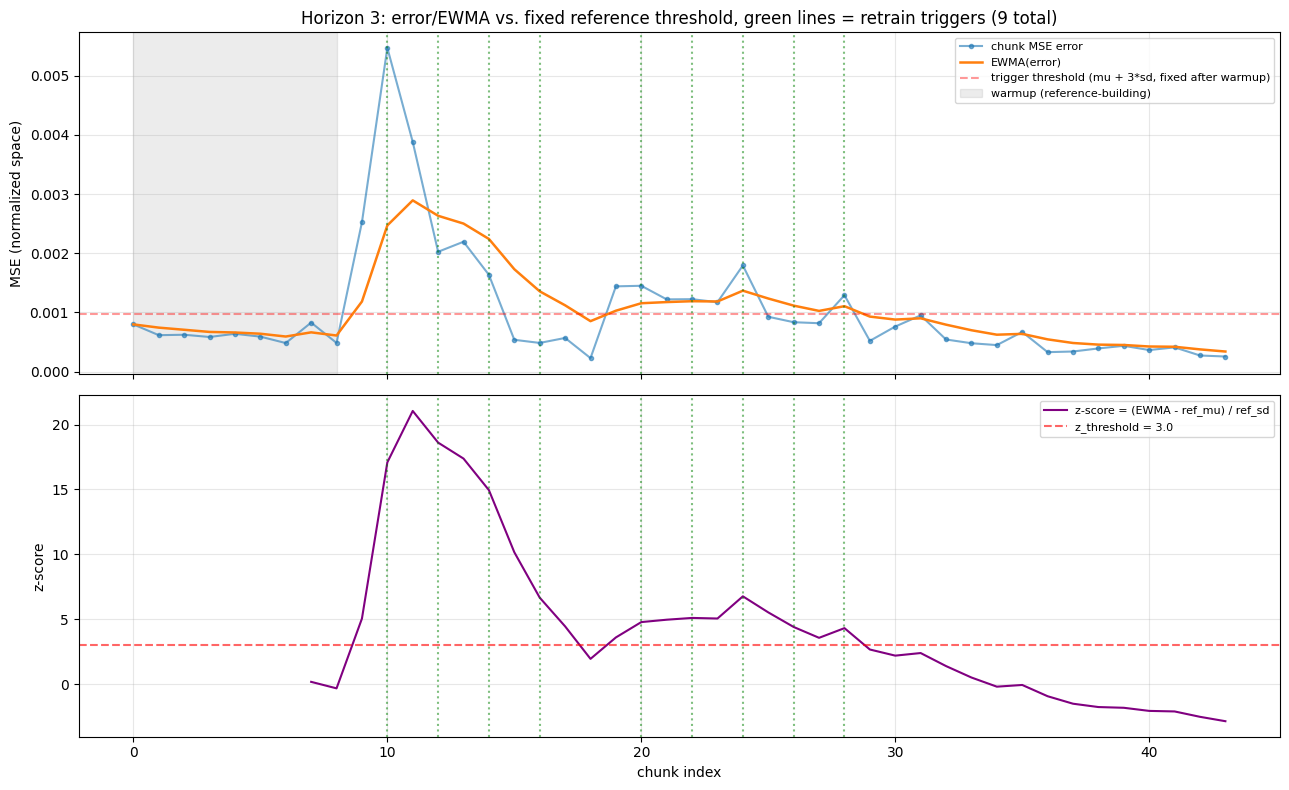

Saved /kaggle/working/drift_debug_h3.png


In [25]:
import matplotlib.pyplot as plt

chunks = [r['chunk'] for r in log_rows]
errs = [r['mse_err'] for r in log_rows]
ewmas = [r['ewma'] for r in log_rows]
zscores = [r['z_score'] for r in log_rows]
trig_chunks = [r['chunk'] for r in log_rows if r['triggered']]
warmup_end = next((r['chunk'] for r in log_rows if not r['in_warmup']), 0)

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
axes[0].plot(chunks, errs, label='chunk MSE error', alpha=0.6, marker='.')
axes[0].plot(chunks, ewmas, label='EWMA(error)', linewidth=1.8)
for r in log_rows:
    if not r['in_warmup'] and r['ref_mu'] == r['ref_mu']:
        thresh = r['ref_mu'] + monitor.z * r['ref_sd']
        axes[0].axhline(thresh, color='red', linestyle='--', alpha=0.4,
                        label='trigger threshold (mu + 3*sd, fixed after warmup)')
        break
axes[0].axvspan(0, warmup_end, color='gray', alpha=0.15, label='warmup (reference-building)')
for c in trig_chunks:
    axes[0].axvline(c, color='green', alpha=0.5, linestyle=':')
axes[0].set_ylabel('MSE (normalized space)')
axes[0].legend(fontsize=8, loc='upper right')
axes[0].set_title(f'Horizon {DEBUG_HORIZON}: error/EWMA vs. fixed reference threshold, '
                  f'green lines = retrain triggers ({len(trig_chunks)} total)')
axes[0].grid(alpha=0.3)

axes[1].plot(chunks, zscores, label='z-score = (EWMA - ref_mu) / ref_sd', color='purple')
axes[1].axhline(monitor.z, color='red', linestyle='--', alpha=0.6, label=f'z_threshold = {monitor.z}')
for c in trig_chunks:
    axes[1].axvline(c, color='green', alpha=0.5, linestyle=':')
axes[1].set_xlabel('chunk index')
axes[1].set_ylabel('z-score')
axes[1].legend(fontsize=8, loc='upper right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
save_path = (Path('/kaggle/working') if IN_KAGGLE else Path('.')) / f'drift_debug_h{DEBUG_HORIZON}.png'
plt.savefig(save_path, dpi=100)
plt.show()
print(f"Saved {save_path}")


## Step 7: Automated Diagnosis — Stabilized Model or Detector Limitation?

Tests the two hypotheses directly against the logged data:
- **Genuinely stabilized**: after the last trigger, z-score stays consistently below
  threshold (a single stray near-miss counts as noise, matching the monitor's own
  `sustain=2` convention).
- **Detector limitation**: two or more chunks after the last trigger exceed the
  threshold without triggering — real elevated error the monitor failed to act on.


In [26]:
if last_trigger is None:
    print("No triggers fired at all -- inspect the full log table above for why "
          "(check whether z-scores ever approached the threshold).")
else:
    after = [r for r in log_rows if r['chunk'] > last_trigger]
    above_thresh_after = [r for r in after if r['z_score'] == r['z_score'] and r['z_score'] > monitor.z]
    mean_z_after = float(np.nanmean([r['z_score'] for r in after]))

    print(f"Chunks after the last trigger (chunk {last_trigger}): {len(after)}")
    print(f"Mean z-score in that region: {mean_z_after:.2f}  (threshold = {monitor.z})")
    print(f"Chunks where z-score EXCEEDED the threshold but did not trigger: {len(above_thresh_after)}")
    if above_thresh_after:
        print("  at chunks:", [r['chunk'] for r in above_thresh_after])

    print()
    if len(above_thresh_after) < 2 and mean_z_after < monitor.z * 0.5:
        print("DIAGNOSIS: error genuinely stabilized well below the reference threshold after "
              "the last adaptation -- the mechanism worked as intended and further correction "
              "was not needed for the rest of the stream.")
        if len(above_thresh_after) == 1:
            print(f"  (one isolated near-miss at chunk {above_thresh_after[0]['chunk']} -- "
                  f"consistent with normal noise, not a sustained pattern the monitor missed.)")
    elif len(above_thresh_after) >= 2:
        print("DIAGNOSIS: multiple elevated-error chunks exist after the last trigger that the "
              "monitor did NOT act on -- consistent with the consecutive-hit requirement "
              "(sustain=2) or the frozen reference window missing genuine later drift. "
              "The detector has a real sensitivity limitation, not just a stabilized model.")
    else:
        print("DIAGNOSIS: mixed signal -- z-score stayed below threshold but not dramatically so. "
              "Inspect the Step 6 plot directly to judge whether this looks like stabilization "
              "or a detector that's just barely missing real fluctuation.")


Chunks after the last trigger (chunk 28): 15
Mean z-score in that region: -0.45  (threshold = 3.0)
Chunks where z-score EXCEEDED the threshold but did not trigger: 0

DIAGNOSIS: error genuinely stabilized well below the reference threshold after the last adaptation -- the mechanism worked as intended and further correction was not needed for the rest of the stream.


## Step 8: Save Phase 4 Results (zipped download)

In [27]:
import zipfile

out_dir = Path('/kaggle/working') if IN_KAGGLE else Path('.')
results = {
    'horizons': HORIZONS,
    'debug_horizon': DEBUG_HORIZON,
    'stream_results': stream_results,
    'debug_log': log_rows,
    'settings': {'stream_chunk': STREAM_CHUNK, 'adapt_lr': ADAPT_LR,
                 'adapt_recent': ADAPT_RECENT, 'adapt_batch_size': ADAPT_BATCH_SIZE,
                 'eval_batch_size': EVAL_BATCH_SIZE, 'spike_lookback_tail': SPIKE_LOOKBACK_TAIL},
}
json_path = out_dir / 'phase4_results.json'
with open(json_path, 'w') as f:
    json.dump(results, f, indent=1, default=float)

zip_path = out_dir / 'kagglephase4_output.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as z:
    z.write(json_path, json_path.name)
    png = out_dir / f'drift_debug_h{DEBUG_HORIZON}.png'
    if png.exists():
        z.write(png, png.name)

print(f"Saved {json_path.name} and {zip_path.name} ({zip_path.stat().st_size/1e6:.2f} MB)")
print("Download from the Output tab -- contains the full static-vs-adaptive streaming results,")
print("the per-chunk drift-detection debug log, and the diagnosis plot.")


Saved phase4_results.json and kagglephase4_output.zip (0.12 MB)
Download from the Output tab -- contains the full static-vs-adaptive streaming results,
the per-chunk drift-detection debug log, and the diagnosis plot.
